# 🌳 Decision Tree Regressor — Unconventional Well Production

**Dataset:** `unconv_MV_v5.csv` (Geostats Guy / Prof. Michael Pyrcz)  
**Target:** `Production` (MCFPD — thousand cubic feet per day)  
**Features used:** `Por` (Porosity %), `Brittle` (Brittleness %)

---

## 📋 Table of Contents
1. [Imports & Setup](#1)
2. [Helper Functions](#2)
3. [Load & Prepare Data](#3)
4. [Feature Selection & Labels](#4)
5. [Correlation Analysis](#5)
6. [Pairplot — Feature Relationships](#6)
7. [Train / Test Split & Validation](#7)
8. [Hyperparameter Tuning — Max Leaf Nodes](#8)
9. [K-Fold Cross Validation](#9)
10. [Final Tuned Model](#10)
11. [Feature Importance](#11)
12. [Tree Visualization](#12)
13. [Key Findings](#13)

---
## 1. Imports & Setup <a id='1'></a>

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import math
import numpy as np
import scipy.stats as st
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, FuncFormatter
from matplotlib.colors import ListedColormap
import seaborn as sns

from sklearn import tree, metrics
from sklearn.tree import _tree
from sklearn.preprocessing import StandardScaler
from sklearn.tree import export_graphviz
from sklearn.model_selection import (
    cross_val_score, train_test_split, GridSearchCV, KFold
)
from sklearn.pipeline import Pipeline
from IPython.display import display, HTML

# ── Global settings ───────────────────────────────────────────────────
cmap = plt.cm.inferno
plt.rc('axes', axisbelow=True)   # grid lines appear behind plot elements
seed = 13                        # random seed for reproducibility

---
## 2. Helper Functions <a id='2'></a>

All plotting and utility functions are defined here before use. Functions credit: Prof. Michael Pyrcz (GeostatsGuy).

In [2]:
def comma_format(x, pos):
    """Format axis tick labels with comma separators (e.g. 1,000,000)."""
    return f'{int(x):,}'


def add_grid():
    """Add major and minor gridlines to the current axes."""
    plt.gca().grid(True, which='major', linewidth=1.0)
    plt.gca().grid(True, which='minor', linewidth=0.2)
    plt.gca().tick_params(which='major', length=7)
    plt.gca().tick_params(which='minor', length=4)
    plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
    plt.gca().yaxis.set_minor_locator(AutoMinorLocator())


def plot_CDF(data, color, alpha=1.0, lw=1, ls='solid', label='none'):
    """Plot an empirical CDF by sorting data and computing cumulative probabilities."""
    cumprob = np.linspace(1, len(data), len(data)) / (len(data) + 1)
    plt.scatter(np.sort(data), cumprob, c=color, alpha=alpha, edgecolor='black', lw=lw, label=label, zorder=10)
    plt.plot(np.sort(data), cumprob, c=color, alpha=alpha, lw=lw, ls=ls, zorder=8)


def feature_rank_plot(pred, metric, mmin, mmax, nominal, title, ylabel, mask):
    """Bar-style feature ranking plot showing correlation magnitude relative to a nominal baseline."""
    mpred = len(pred)
    mask_low  = nominal - mask * (nominal - mmin)
    mask_high = nominal + mask * (mmax - nominal)
    m = mpred + 1
    plt.plot(pred, metric, color='black', zorder=20)
    plt.scatter(pred, metric, marker='o', s=10, color='black', zorder=100)
    plt.plot([-0.5, m - 1.5], [0.0, 0.0], 'r--', linewidth=1.0, zorder=1)
    plt.fill_between(np.arange(0, mpred), np.zeros(mpred), metric,
                     where=(metric < nominal), interpolate=True, color='dodgerblue', alpha=0.3)
    plt.fill_between(np.arange(0, mpred), np.zeros(mpred), metric,
                     where=(metric > nominal), interpolate=True, color='lightcoral', alpha=0.3)
    plt.fill_between(np.arange(0, mpred), np.full(mpred, mask_low), metric,
                     where=(metric < mask_low), interpolate=True, color='blue', alpha=0.8, zorder=10)
    plt.fill_between(np.arange(0, mpred), np.full(mpred, mask_high), metric,
                     where=(metric > mask_high), interpolate=True, color='red', alpha=0.8, zorder=10)
    plt.xlabel('Predictor Features'); plt.ylabel(ylabel); plt.title(title)
    plt.ylim(mmin, mmax); plt.xlim([-0.5, m - 1.5]); add_grid()


def plot_corr(corr_matrix, title, limits, mask):
    """Visualize a correlation matrix with a masked colormap (white = weak correlation)."""
    my_colormap  = plt.get_cmap('RdBu_r', 256)
    newcolors    = my_colormap(np.linspace(0, 1, 256))
    white        = np.array([1, 1, 1, 1])
    white_low    = int(128 - mask * 128)
    white_high   = int(128 + mask * 128)
    newcolors[white_low:white_high, :] = white
    newcmp = ListedColormap(newcolors)
    m  = corr_matrix.shape[0]
    im = plt.matshow(corr_matrix, fignum=0, vmin=-limits, vmax=limits, cmap=newcmp)
    plt.xticks(range(m), corr_matrix.columns)
    ax = plt.gca()
    ax.xaxis.set_label_position('bottom'); ax.xaxis.tick_bottom()
    plt.yticks(range(m), corr_matrix.columns)
    plt.colorbar(im, orientation='vertical'); plt.title(title)
    for i in range(m):
        plt.plot([i - 0.5, i - 0.5], [-0.5, m - 0.5], color='black')
        plt.plot([-0.5, m - 0.5], [i - 0.5, i - 0.5], color='black')
    plt.ylim([-0.5, m - 0.5]); plt.xlim([-0.5, m - 0.5])


def display_sidebyside(*args):
    """Render multiple DataFrames side by side in a Jupyter cell."""
    html_str = ''.join(df.head().to_html() for df in args)
    display(HTML(f'<div style="display:flex;gap:20px">{html_str}</div>'))


def check_tree_model(model, X1_train, X1_test, X2_train, X2_test,
                     X_min, X_max, y_train, y_test, Y_min, Y_max, title):
    """
    Actual vs. predicted scatter plot with conditional statistics (mean, IQR)
    overlaid for both train and test sets.
    """
    y_hat_train = model.predict(np.c_[X1_train, X2_train])
    y_hat_test  = model.predict(np.c_[X1_test,  X2_test])

    df_cross       = pd.DataFrame({'y_test': y_test, 'y_hat_test': y_hat_test})
    df_cross_train = pd.DataFrame({'y_train': y_train, 'y_hat_train': y_hat_train})

    plt.scatter(y_train, y_hat_train, s=15, c='blue', marker='o', alpha=0.7,
                linewidths=0.3, edgecolors='black', label='Train', zorder=10)
    plt.scatter(y_test, y_hat_test, s=15, c='red', marker='s', alpha=0.7,
                linewidths=0.3, edgecolors='black', label='Test', zorder=10)

    for y_hat in set(np.concatenate([y_hat_test, y_hat_train])):
        plt.plot([Y_min, Y_max], [y_hat, y_hat], c='black', alpha=0.2, ls='--', zorder=1)

    plt.arrow(Y_min, Y_min, Y_max - Y_min, Y_max - Y_min,
              width=0.02, color='black', head_length=0.0, head_width=0.0)

    MSE_train = metrics.mean_squared_error(y_train, y_hat_train)
    MSE_test  = metrics.mean_squared_error(y_test,  y_hat_test)
    plt.gca().add_patch(plt.Rectangle(
        (Y_min + 0.6 * (Y_max - Y_min), Y_min + 0.08 * (Y_max - Y_min)),
        0.38 * (Y_max - Y_min), 0.14 * (Y_max - Y_min),
        lw=0.5, ec='black', fc='white', zorder=100))
    plt.annotate(f'MSE Testing:  {MSE_test:,.0f}',
                 (Y_min + 0.62 * (Y_max - Y_min), Y_min + 0.18 * (Y_max - Y_min)), zorder=1000)
    plt.annotate(f'MSE Training: {MSE_train:,.0f}',
                 (Y_min + 0.62 * (Y_max - Y_min), Y_min + 0.12 * (Y_max - Y_min)), zorder=1000)

    plt.title(title)
    plt.xlabel('Actual Production (MCFPD)'); plt.ylabel('Estimated Production (MCFPD)')
    plt.xlim([Y_min, Y_max]); plt.ylim([Y_min, Y_max]); plt.legend(loc='upper left')
    plt.gca().xaxis.set_major_formatter(FuncFormatter(comma_format))
    plt.gca().yaxis.set_major_formatter(FuncFormatter(comma_format))
    add_grid()

---
## 3. Load & Prepare Data <a id='3'></a>

In [3]:
df2 = pd.read_csv(
    'https://raw.githubusercontent.com/GeostatsGuy/GeoDataSets/master/unconv_MV_v5.csv'
)
print(f'Raw shape: {df2.shape}')
df2.info()

Raw shape: (200, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Well     200 non-null    int64  
 1   Por      200 non-null    float64
 2   Perm     200 non-null    float64
 3   AI       200 non-null    float64
 4   Brittle  200 non-null    float64
 5   TOC      200 non-null    float64
 6   VR       200 non-null    float64
 7   Prod     200 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 12.6 KB


In [4]:
# Reset index, sample 70% for demonstration, rename target column
df2 = df2.reset_index()
df2 = df2.sample(frac=0.7, random_state=seed)
df2 = df2.rename(columns={'Prod': 'Production'})

print(f'Working shape: {df2.shape}')
df2.describe().transpose()

Working shape: (140, 9)


,count,mean,std,min,25%,50%,75%,max
index,140.0,98.335714,57.913556,3.000000,46.750000,96.500000,148.500000,199.000000
Well,140.0,99.335714,57.913556,4.000000,47.750000,97.500000,149.500000,200.000000
Por,140.0,14.897357,3.181639,6.550000,12.547500,14.855000,17.690000,23.550000
Perm,140.0,4.306429,1.765834,1.130000,3.082500,3.990000,5.260000,9.870000
AI,140.0,2.993929,0.576396,1.280000,2.547500,2.960000,3.415000,4.630000
Brittle,140.0,48.345429,14.157619,10.940000,38.067500,50.735000,58.100000,84.330000
TOC,140.0,0.990786,0.495319,-0.190000,0.617500,0.990000,1.355000,2.180000
VR,140.0,1.979857,0.305251,0.930000,1.795000,1.970000,2.150000,2.870000
Production,140.0,4294.971019,1046.037871,2119.315516,3529.173873,4249.768369,5109.236909,6662.622385


---
## 4. Feature Selection & Labels <a id='4'></a>

We use **Porosity** and **Brittleness** as predictor features — two key drivers of unconventional well productivity.

In [5]:
y_name = 'Production'
x_name = ['Por', 'Brittle']

y = df2[y_name]
X = df2[x_name]

# Axis ranges for visualization (from domain knowledge)
X_min = [5.0,  0.0]
X_max = [25.0, 100.0]
Y_min = 1000.0
Y_max = 9000.0

x_label = ['Porosity', 'Brittleness']
y_label  = 'Production'
X_unit   = ['%', '%']
y_unit   = 'MCFPD'

x_labelunit = [f'{x_label[i]} ({X_unit[i]})' for i in range(len(x_name))]
y_labelunit  = f'{y_label} ({y_unit})'

# Combined DataFrame for correlation and plotting
df = pd.concat([X, y], axis=1)
pred     = X.columns.tolist()
features = df.columns.tolist()
res      = y.name

print(f'Features : {pred}')
print(f'Response : {res}')

Features : ['Por', 'Brittle']
Response : Production


---
## 5. Correlation Analysis <a id='5'></a>

We compute the Pearson correlation matrix and rank features by their correlation with production.

Correlation with Production:
Por        0.869271
Brittle    0.214952
Name: Production, dtype: float64


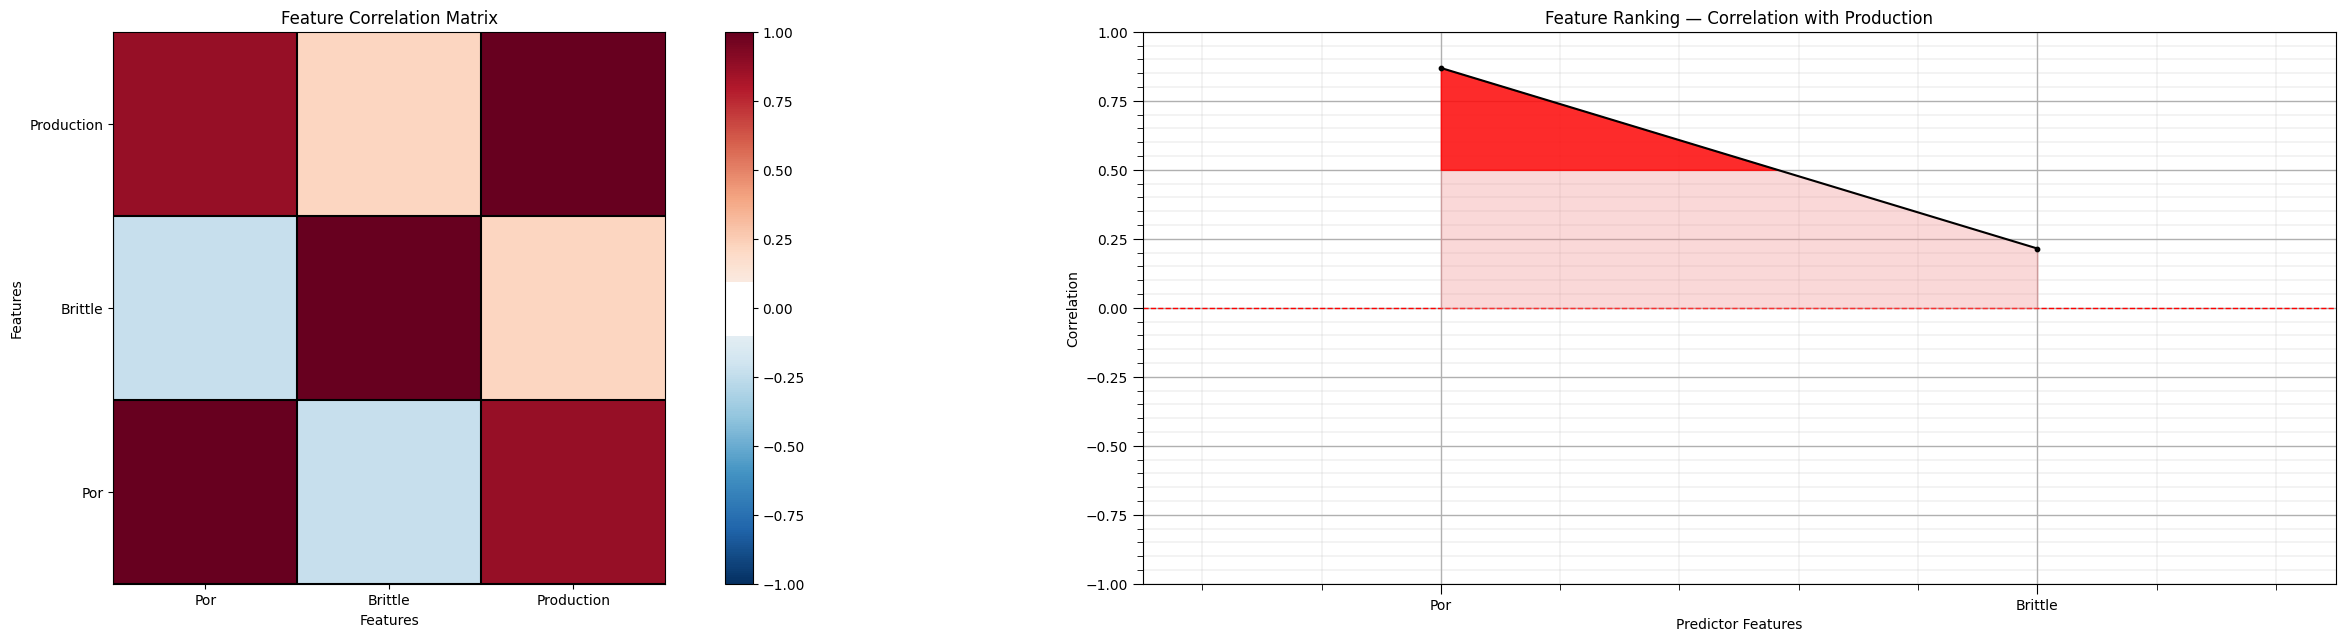

In [7]:
corr_matrix = df.corr()
correlation  = corr_matrix.iloc[:, -1].values[:-1]   # correlations with Production (exclude self)

print('Correlation with Production:')
print(corr_matrix.iloc[:, -1].drop(y_name))

fig = plt.figure(figsize=(14, 8))

plt.subplot(121)
plot_corr(corr_matrix, 'Feature Correlation Matrix', 1.0, 0.1)
plt.xlabel('Features'); plt.ylabel('Features')

plt.subplot(122)
feature_rank_plot(x_name, correlation, -1.0, 1.0, 0.0,
                  f'Feature Ranking — Correlation with {y_name}', 'Correlation', 0.5)

plt.subplots_adjust(right=2.0, top=0.8, wspace=0.2)
plt.show()

---
## 6. Pairplot — Feature Relationships <a id='6'></a>

The pairplot shows scatter plots (upper), KDE density (lower), and histograms (diagonal) for all feature pairs.

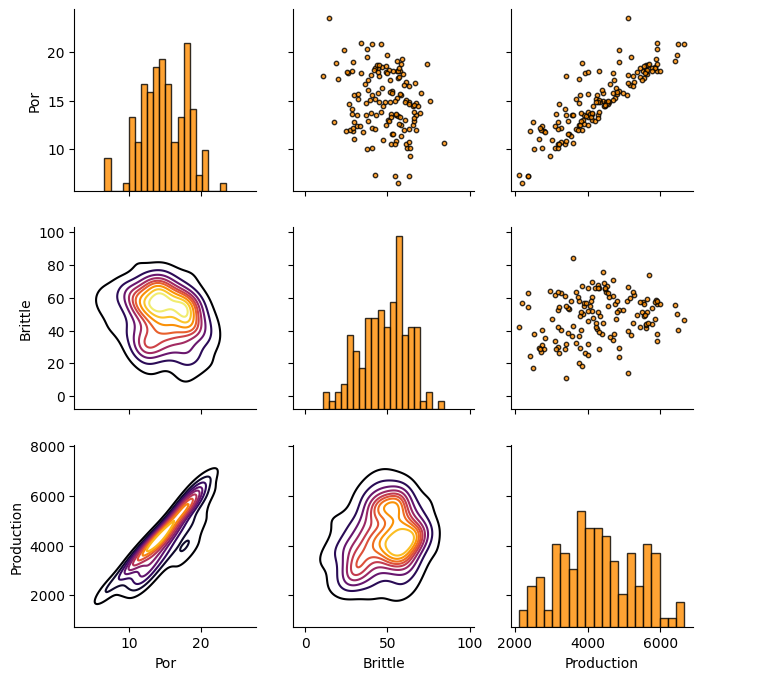

In [8]:
# Upper triangle: scatter plots | Diagonal: histograms | Lower triangle: KDE density
pairgrid = sns.PairGrid(df, vars=x_name + [y_name])
pairgrid = pairgrid.map_upper(plt.scatter, color='darkorange', edgecolor='black', alpha=0.8, s=10)
pairgrid = pairgrid.map_diag(plt.hist, bins=20, color='darkorange', alpha=0.8, edgecolor='k')
pairgrid = pairgrid.map_lower(sns.kdeplot, cmap=plt.cm.inferno, alpha=1.0, n_levels=10)
pairgrid.add_legend()
plt.subplots_adjust(right=0.9, top=0.9, wspace=0.2, hspace=0.2)
plt.show()

---
## 7. Train / Test Split & Validation <a id='7'></a>

We use a 75/25 train-test split and verify distributions are similar using histograms and CDFs.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=73073
)
df_train = pd.concat([X_train, y_train], axis=1)
df_test  = pd.concat([X_test,  y_test],  axis=1)

print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')
print()
print('Train / Test summary statistics:')
display_sidebyside(
    df_train.describe().loc[['count', 'mean', 'std', 'min', 'max']],
    df_test.describe().loc[['count', 'mean', 'std', 'min', 'max']]
)

Train: 105 samples | Test: 35 samples

Train / Test summary statistics:


,Por,Brittle,Production
count,105.000000,105.000000,105.000000
mean,14.859238,48.861143,4284.629437
std,3.057228,14.432050,990.570518
min,7.220000,10.940000,2351.289487
max,23.550000,84.330000,6662.622385
,Por,Brittle,Production
count,35.000000,35.000000,35.000000
mean,15.011714,46.798286,4325.995766
std,3.574467,13.380910,1212.681804
min,6.550000,20.120000,2119.315516


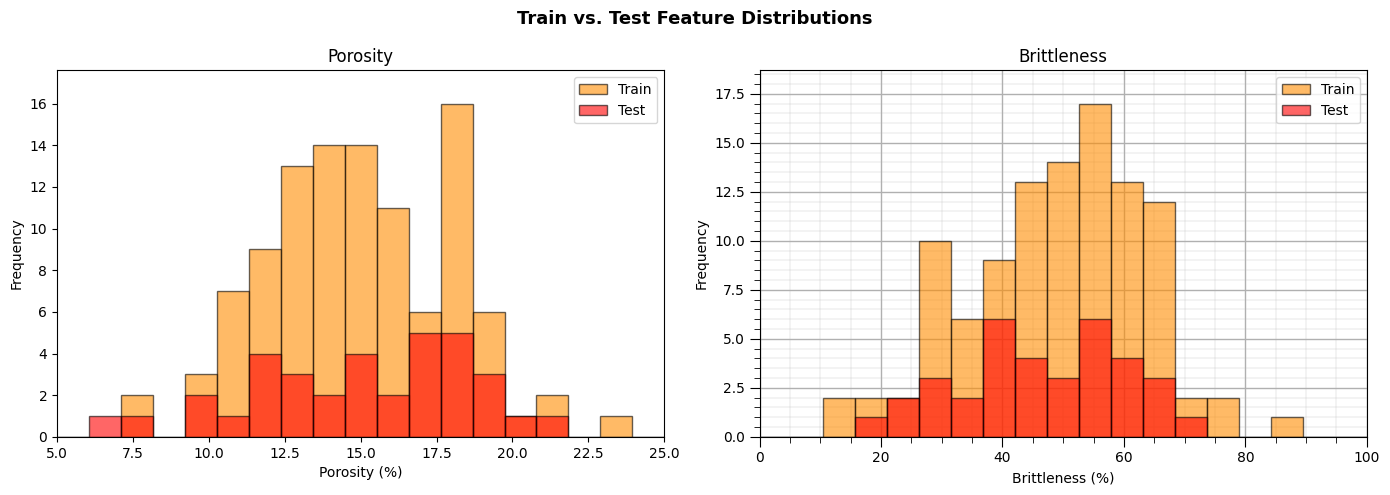

In [10]:
# Histograms — confirm similar distributions in train and test
nbins = 20
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, ax in enumerate(axes):
    freq1, _, _ = ax.hist(df_train[x_name[i]],
                          bins=np.linspace(X_min[i], X_max[i], nbins),
                          alpha=0.6, edgecolor='black', color='darkorange', label='Train')
    freq2, _, _ = ax.hist(df_test[x_name[i]],
                          bins=np.linspace(X_min[i], X_max[i], nbins),
                          alpha=0.6, edgecolor='black', color='red', label='Test')
    ax.set_xlabel(x_labelunit[i]); ax.set_ylabel('Frequency')
    ax.set_title(x_label[i]); ax.set_xlim([X_min[i], X_max[i]])
    ax.set_ylim([0, max(freq1.max(), freq2.max()) * 1.1])
    add_grid(); ax.legend(loc='upper right')

plt.suptitle('Train vs. Test Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

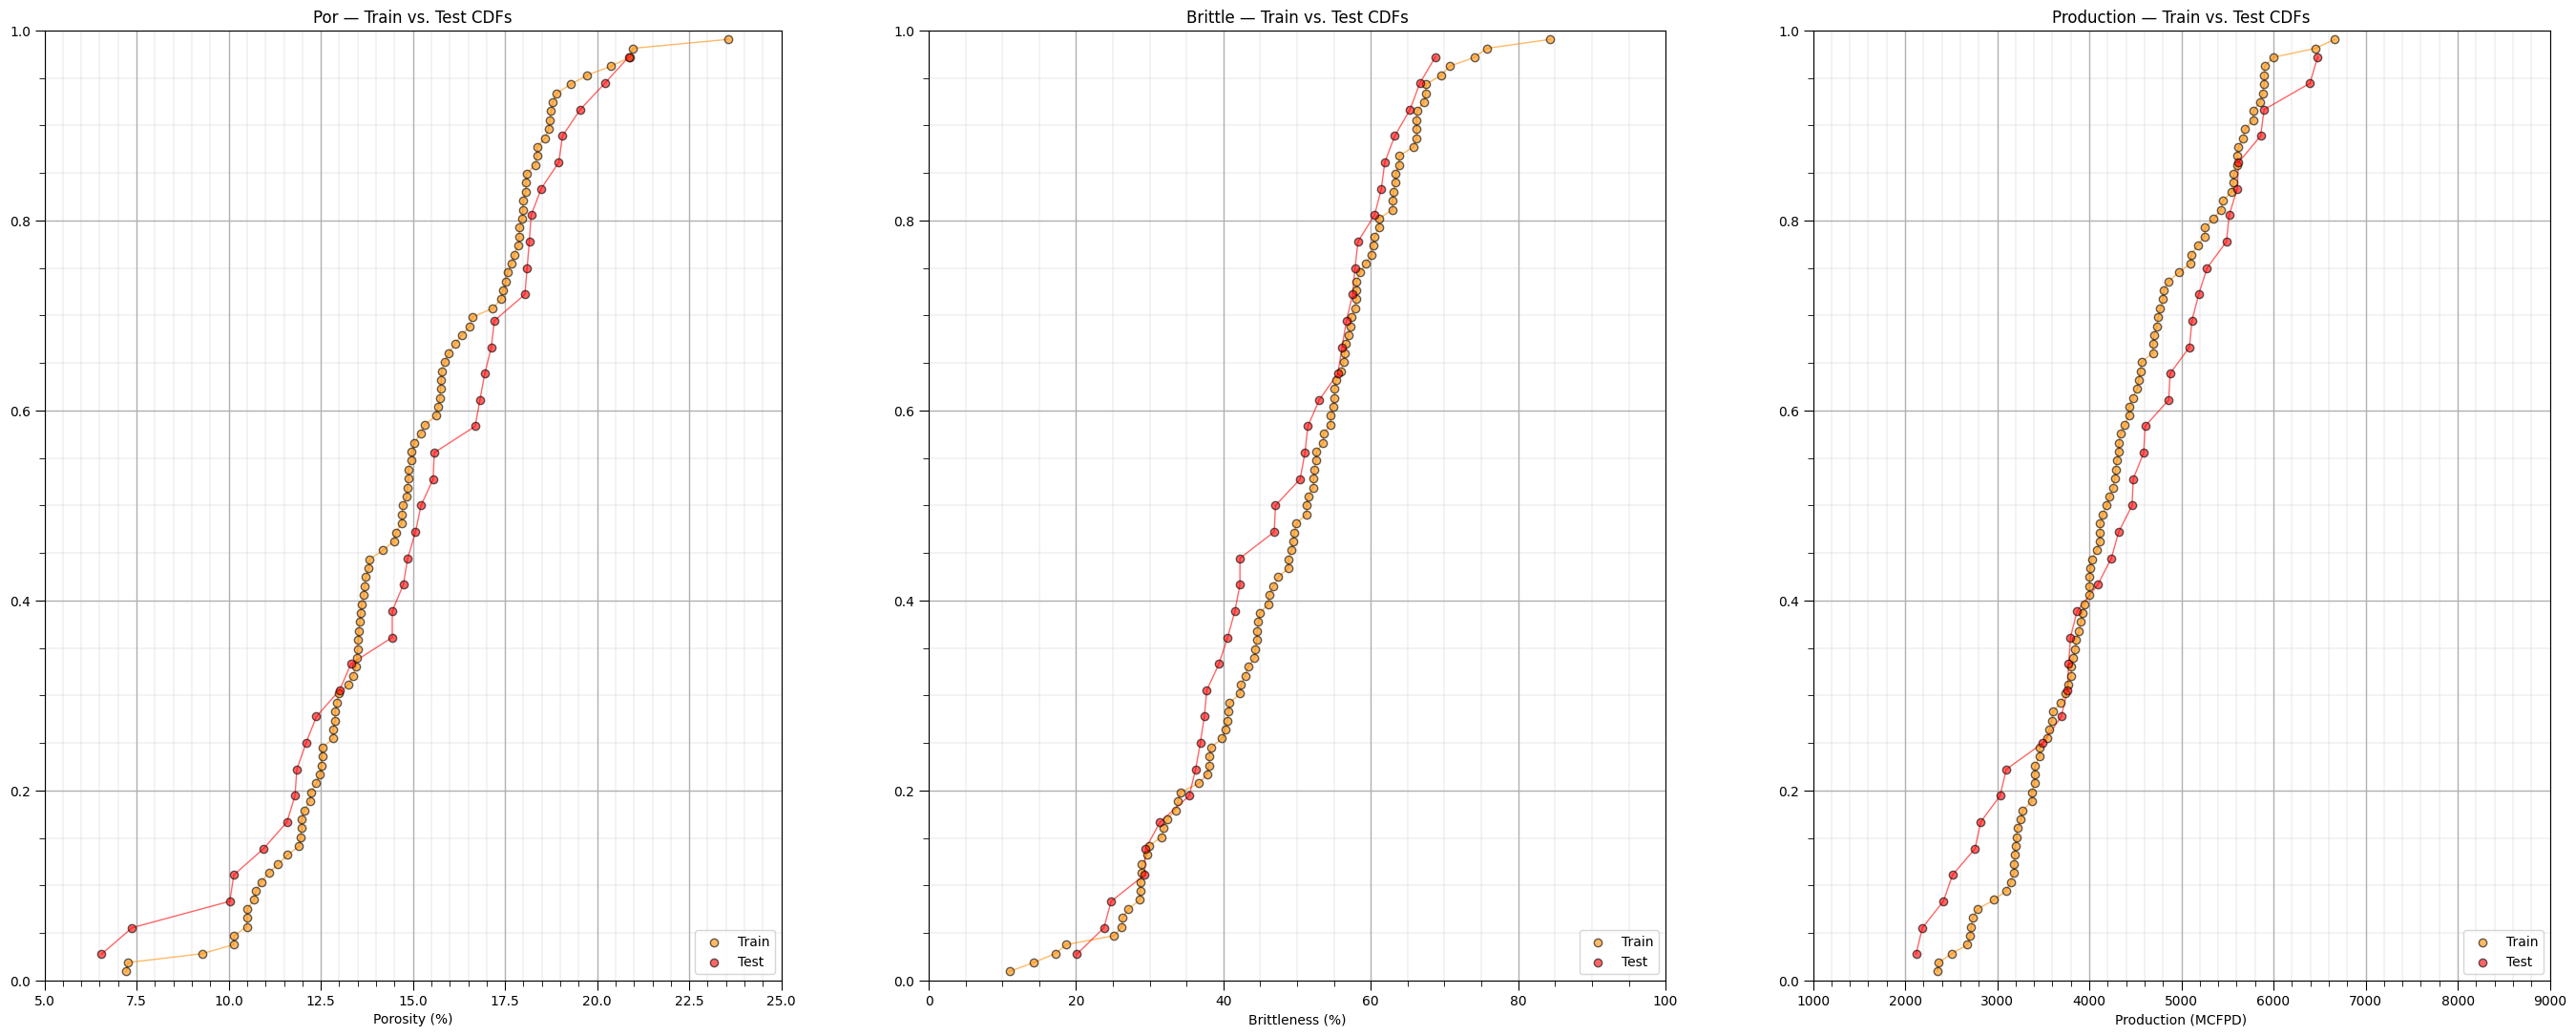

In [11]:
# CDFs — finer-grained comparison of train vs. test distributions
fig = plt.figure(figsize=(14, 5))

for i, (name, xmin, xmax, label) in enumerate(
    zip(x_name + [y_name],
        X_min + [Y_min], X_max + [Y_max],
        x_labelunit + [y_labelunit]), start=1):
    plt.subplot(1, 3, i)
    plot_CDF(df_train[name] if name != y_name else y_train, 'darkorange', alpha=0.6, label='Train')
    plot_CDF(df_test[name]  if name != y_name else y_test,  'red',        alpha=0.6, label='Test')
    plt.xlabel(label); plt.xlim([xmin, xmax]); plt.ylim([0, 1])
    plt.title(f'{name} — Train vs. Test CDFs'); add_grid(); plt.legend(loc='lower right')

plt.subplots_adjust(right=2.0, top=2.1, wspace=0.2)
plt.show()

---
## 8. Hyperparameter Tuning — Max Leaf Nodes <a id='8'></a>

We sweep over all possible `max_leaf_nodes` values and evaluate MSE on the test set to find the sweet spot between underfitting and overfitting.

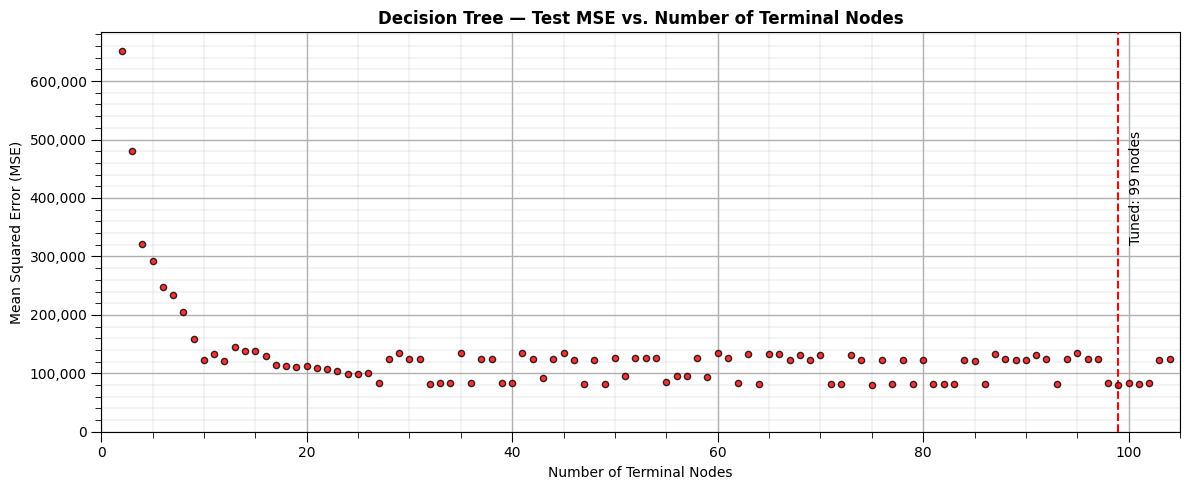

Optimal terminal nodes (test MSE): 99


In [12]:
trees     = []
MSE_CV    = []
node_CV   = []

inode = 2
while inode < len(X_train):
    tree_model = tree.DecisionTreeRegressor(
        min_samples_leaf=1, max_leaf_nodes=inode
    ).fit(X_train.values, y_train.values)

    trees.append(tree_model)
    y_hat = tree_model.predict(np.c_[X_test[x_name[0]], X_test[x_name[1]]])
    MSE_CV.append(metrics.mean_squared_error(y_test, y_hat))

    all_nodes      = tree_model.tree_.node_count
    decision_nodes = sum(1 for f in tree_model.tree_.feature if f != _tree.TREE_UNDEFINED)
    node_CV.append(all_nodes - decision_nodes)
    inode += 1

tuned_node  = node_CV[np.argmin(MSE_CV)]
max_MSE_CV  = np.max(MSE_CV)

plt.figure(figsize=(12, 5))
plt.scatter(node_CV, MSE_CV, s=20, c='red', edgecolors='black', alpha=0.8, zorder=20)
plt.vlines(tuned_node, 0, 1.05 * max_MSE_CV, lw=1.5, ls='--', color='red', zorder=10)
plt.annotate(f'Tuned: {tuned_node} nodes', (tuned_node + 1, max_MSE_CV * 0.5), rotation=90, zorder=30)
plt.title('Decision Tree — Test MSE vs. Number of Terminal Nodes', fontweight='bold')
plt.xlabel('Number of Terminal Nodes'); plt.ylabel('Mean Squared Error (MSE)')
plt.xlim(0, len(X_train)); plt.ylim(0, 1.05 * max_MSE_CV)
plt.gca().yaxis.set_major_formatter(FuncFormatter(comma_format))
add_grid(); plt.tight_layout(); plt.show()
print(f'Optimal terminal nodes (test MSE): {tuned_node}')

---
## 9. K-Fold Cross Validation <a id='9'></a>

K-Fold CV produces smoother and more reliable estimates than a single train-test evaluation by averaging across multiple data splits.

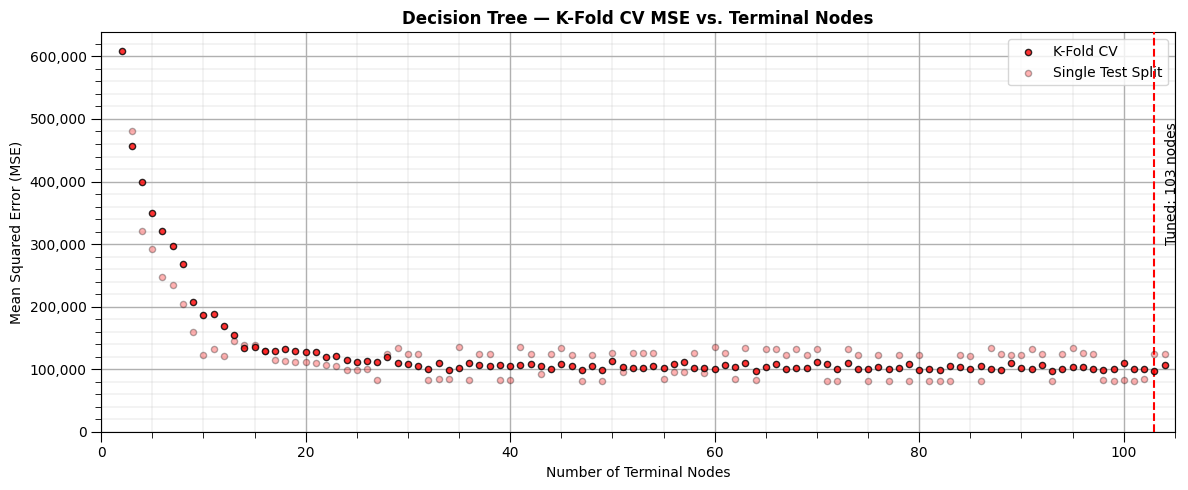

K-Fold optimal terminal nodes: 103


In [13]:
MSE_kF  = []
node_kF = []

inode = 2
while inode < len(X_train):
    tree_model = tree.DecisionTreeRegressor(max_leaf_nodes=inode).fit(X_train.values, y_train.values)
    scores = cross_val_score(
        estimator=tree_model,
        X=np.c_[df[x_name[0]], df[x_name[1]]],
        y=df[y_name], cv=5, n_jobs=-1,
        scoring='neg_mean_squared_error'
    )
    MSE_kF.append(abs(scores.mean()))
    all_nodes      = tree_model.tree_.node_count
    decision_nodes = sum(1 for f in tree_model.tree_.feature if f != _tree.TREE_UNDEFINED)
    node_kF.append(all_nodes - decision_nodes)
    inode += 1

tuned_node_kF = node_kF[np.argmin(MSE_kF)]
max_MSE_kF    = np.max(MSE_kF)

plt.figure(figsize=(12, 5))
plt.scatter(node_kF,  MSE_kF,  s=20, c='red',   edgecolors='black', alpha=0.8, zorder=40, label='K-Fold CV')
plt.scatter(node_CV,  MSE_CV,  s=20, c='red',   edgecolors='black', alpha=0.3, zorder=20, label='Single Test Split')
plt.vlines(tuned_node_kF, 0, 1.05 * max_MSE_kF, lw=1.5, ls='--', color='red', zorder=10)
plt.annotate(f'Tuned: {tuned_node_kF} nodes', (tuned_node_kF + 1, max_MSE_kF * 0.5), rotation=90, zorder=30)
plt.title('Decision Tree — K-Fold CV MSE vs. Terminal Nodes', fontweight='bold')
plt.xlabel('Number of Terminal Nodes'); plt.ylabel('Mean Squared Error (MSE)')
plt.xlim(0, len(X_train)); plt.ylim(0, 1.05 * max_MSE_kF); plt.legend(loc='upper right')
plt.gca().yaxis.set_major_formatter(FuncFormatter(comma_format))
add_grid(); plt.tight_layout(); plt.show()
print(f'K-Fold optimal terminal nodes: {tuned_node_kF}')

---
## 10. Final Tuned Model <a id='10'></a>

We retrain the decision tree with the K-Fold tuned `max_leaf_nodes` and evaluate on both train and test sets.

In [39]:
def fit_decision_tree(max_leaf_nodes, X_train, y_train, X_test, y_test, random_state=72):
    """
    Fit a Decision Tree regressor and return metrics for both train and test sets.

    Parameters
    ----------
    max_leaf_nodes : int  — maximum number of leaf (terminal) nodes
    X_train, y_train     — training features and target
    X_test, y_test       — testing features and target
    random_state   : int — random seed for reproducibility

    Returns
    -------
    model        — fitted DecisionTreeRegressor
    y_pred_test  — test set predictions
    y_pred_train — train set predictions
    metrics_dict — dict with mse_train, mse_test, r2_train, r2_test
    """
    model = tree.DecisionTreeRegressor(
        max_leaf_nodes=12,
        min_samples_leaf=1,
        random_state=random_state
    )
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    metrics_dict = {
        'MSE Train': metrics.mean_squared_error(y_train, y_pred_train),
        'MSE Test':  metrics.mean_squared_error(y_test,  y_pred_test),
        'R² Train':  metrics.r2_score(y_train, y_pred_train),
        'R² Test':   metrics.r2_score(y_test,  y_pred_test),
    }
    return model, y_pred_test, y_pred_train, metrics_dict


# ── Train final model ─────────────────────────────────────────────────
MAX_LEAF_NODES = tuned_node_kF

final_model, y_pred_test, y_pred_train, final_metrics = fit_decision_tree(
    MAX_LEAF_NODES, X_train, y_train, X_test, y_test
)

print(f'Final model — max_leaf_nodes = {MAX_LEAF_NODES}')
print()
for k, v in final_metrics.items():
    print(f'  {k}: {v:,.3f}')

Final model — max_leaf_nodes = 103

  MSE Train: 55,056.329
  MSE Test: 121,846.757
  R² Train: 0.943
  R² Test: 0.915


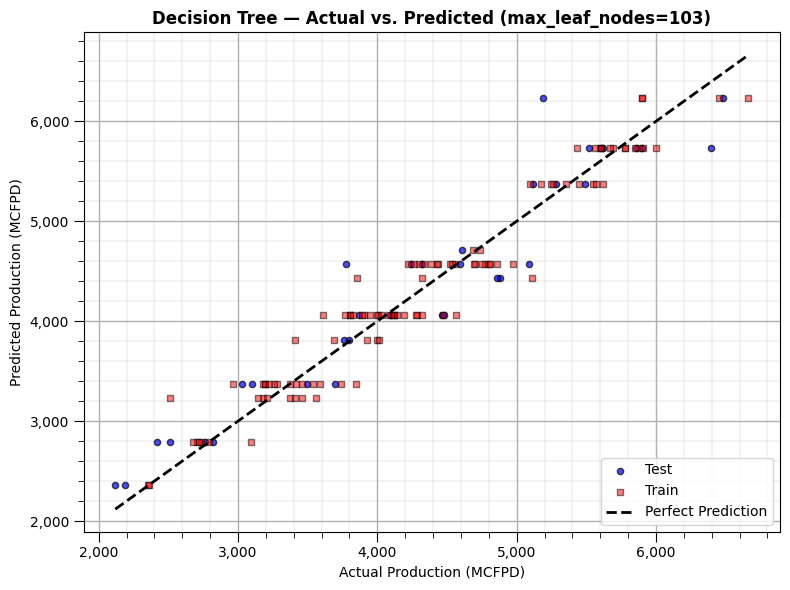

In [40]:
# Actual vs. predicted — train and test
fig = plt.figure(figsize=(8, 6))

plt.scatter(y_test,  y_pred_test,  alpha=0.7, color='blue', edgecolor='black', label='Test',  s=20)
plt.scatter(y_train, y_pred_train, alpha=0.5, color='red',  edgecolor='black', label='Train', marker='s', s=15)

ref_min = min(y_test.min(), y_train.min())
ref_max = max(y_test.max(), y_train.max())
plt.plot([ref_min, ref_max], [ref_min, ref_max], 'k--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Production (MCFPD)'); plt.ylabel('Predicted Production (MCFPD)')
plt.title(f'Decision Tree — Actual vs. Predicted (max_leaf_nodes={MAX_LEAF_NODES})', fontweight='bold')
plt.gca().xaxis.set_major_formatter(FuncFormatter(comma_format))
plt.gca().yaxis.set_major_formatter(FuncFormatter(comma_format))
plt.legend(loc='lower right')
add_grid(); plt.tight_layout(); plt.show()

---
## 11. Feature Importance <a id='11'></a>

Decision trees measure feature importance as the total reduction in impurity (MSE for regression) attributable to each feature across all splits.

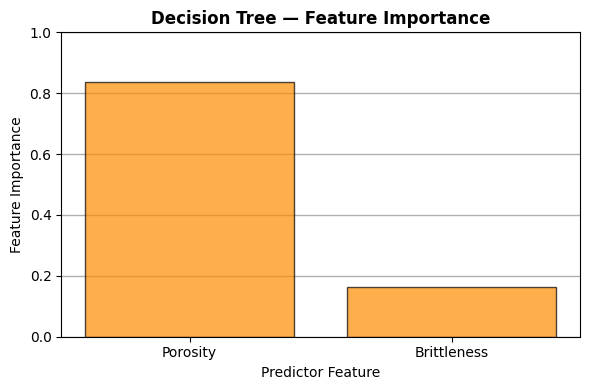

  Porosity: 0.836
  Brittleness: 0.164


In [41]:
plt.figure(figsize=(6, 4))
plt.bar(x_label, final_model.feature_importances_,
        edgecolor='black', color='darkorange', alpha=0.7)
plt.xlabel('Predictor Feature'); plt.ylabel('Feature Importance')
plt.title('Decision Tree — Feature Importance', fontweight='bold')
plt.ylim([0, 1])
plt.gca().yaxis.grid(True, which='major', linewidth=1.0)
plt.gca().yaxis.grid(True, which='minor', linewidth=0.2)
plt.tight_layout(); plt.show()

for name, imp in zip(x_label, final_model.feature_importances_):
    print(f'  {name}: {imp:.3f}')

---
## 12. Tree Visualization <a id='12'></a>

Plotting the tree structure reveals the exact split rules learned from the data.

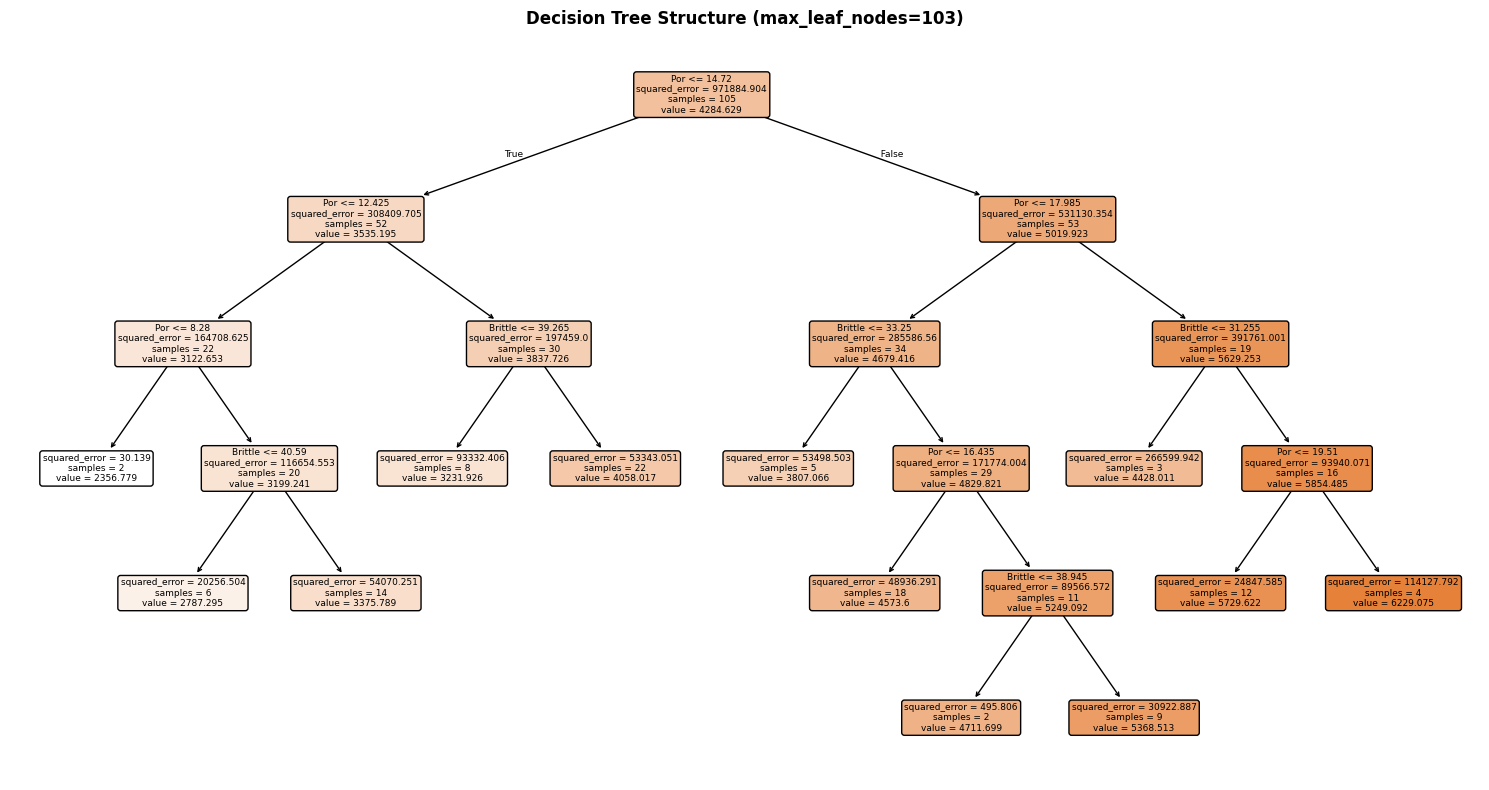

In [42]:
fig = plt.figure(figsize=(15, 8))
_ = tree.plot_tree(
    final_model,
    feature_names=list(x_name),
    filled=True,
    impurity=True,
    rounded=True
)
plt.title(f'Decision Tree Structure (max_leaf_nodes={MAX_LEAF_NODES})', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 13. Key Findings <a id='13'></a>

| # | Finding | Detail |
|---|---|---|
| 1 | **Brittleness dominates** | Feature importance shows Brittleness drives the majority of splits |
| 2 | **Optimal complexity** | K-Fold CV identifies the sweet spot — MSE flattens or rises beyond the tuned node count, confirming overfitting at higher complexity |
| 3 | **K-Fold is smoother** | K-Fold CV curve is less noisy than single train-test evaluation — more reliable for tuning |
| 4 | **Shallow trees generalise** | For this 2-feature dataset, a relatively small number of leaf nodes captures the main patterns |
| 5 | **optimum leaf nodes** | if we take the 103 leaf nodes from K Fold, it will be a overfitting problem. as we can see from the graph after 10/11 leaf nodes, the graph more or less same, we will take 11 to reduce the overfitting issue.
| 6 | **plot of MSE vs max leaf nodes** | MSE vs leaf nodes shifts between runs due to random test set composition.
---
